<a href="https://colab.research.google.com/github/ankit-git-bit/Minor-research-project-/blob/main/MRP_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

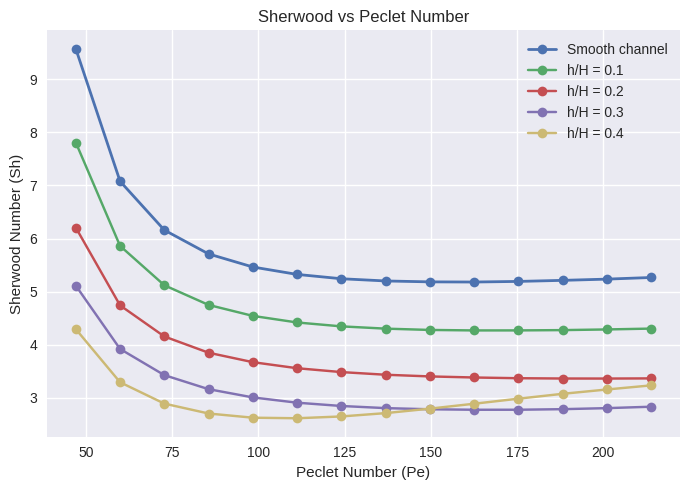

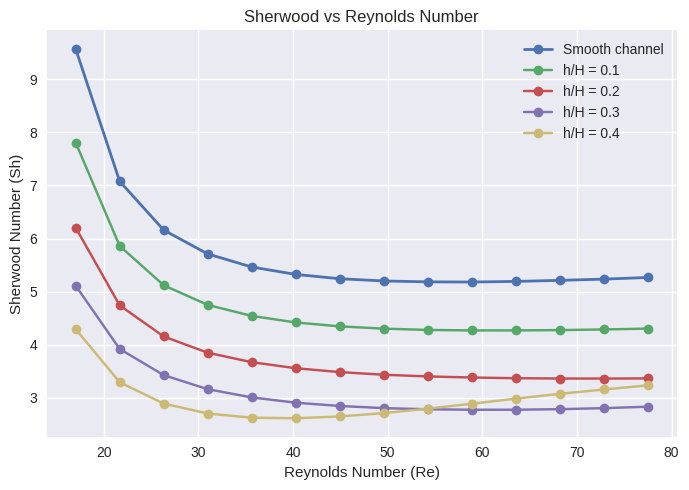

/tmp/ipykernel_1747/3489972198.py:128: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


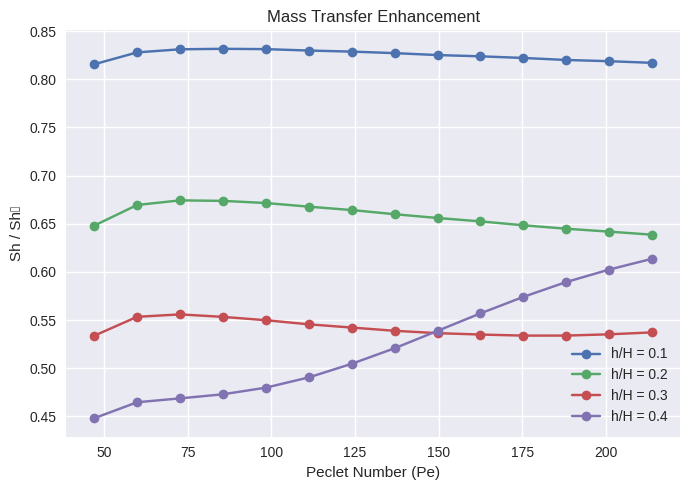

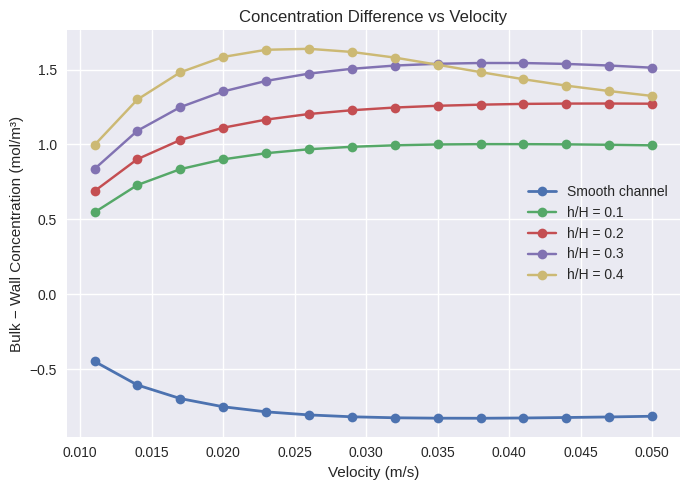

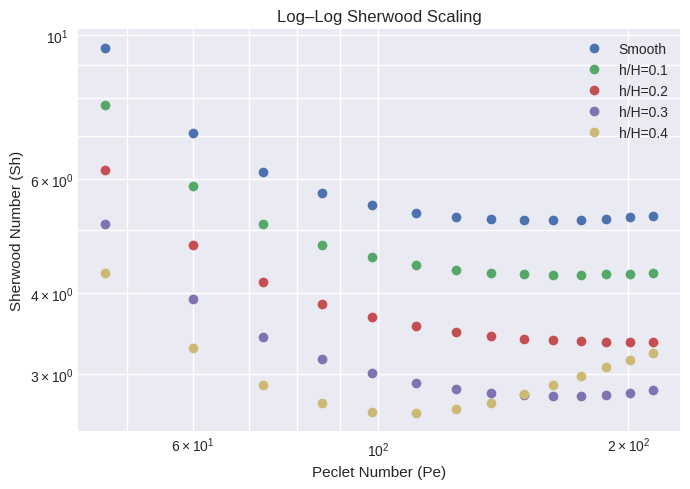


Sherwood scaling relation:
Sh ~ Pe^-0.311


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# ------------------------------------------------
# LOAD SMOOTH CHANNEL DATA
# ------------------------------------------------
base = pd.read_csv(
    "without_obs.txt",
    sep=r"\s+",
    comment="%",
    header=None,
    engine="python"
)

base.columns = [
    "u_in","Re","Pe","c_bulk","Sc","c_wall","Sh","PEC"
]

# Fix Sherwood sign
base["Sh"] = np.abs(base["Sh"])

# Remove entrance region outlier
base = base[base["Pe"] > 40]

# Concentration difference
base["delta_c"] = base["c_bulk"] - base["c_wall"]

base = base.sort_values("Pe")

# ------------------------------------------------
# LOAD OBSTRUCTION DATA
# ------------------------------------------------
obs = pd.read_csv(
    "mrp_withobs.txt",
    sep=r"\s+",
    comment="%",
    header=None,
    engine="python"
)

# COMSOL repeats columns → keep first block
obs = obs.iloc[:,0:8]

obs.columns = [
    "u_in","h_ratio","Re","Pe","c_bulk","Sc","c_wall","Sh"
]

# Fix Sherwood sign
obs["Sh"] = np.abs(obs["Sh"])

# Remove entrance region
obs = obs[obs["Pe"] > 40]

# Concentration difference
obs["delta_c"] = obs["c_bulk"] - obs["c_wall"]

obs = obs.sort_values("Pe")

ratios = sorted(obs["h_ratio"].unique())

# ------------------------------------------------
# 1 SHERWOOD vs PECLET
# ------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(base["Pe"], base["Sh"],
         "o-", linewidth=2, label="Smooth channel")

for r in ratios:
    temp = obs[obs["h_ratio"] == r]
    plt.plot(temp["Pe"], temp["Sh"],
             "o-", label=f"h/H = {r}")

plt.xlabel("Peclet Number (Pe)")
plt.ylabel("Sherwood Number (Sh)")
plt.title("Sherwood vs Peclet Number")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 2 SHERWOOD vs REYNOLDS
# ------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(base["Re"], base["Sh"],
         "o-", linewidth=2, label="Smooth channel")

for r in ratios:
    temp = obs[obs["h_ratio"] == r]
    plt.plot(temp["Re"], temp["Sh"],
             "o-", label=f"h/H = {r}")

plt.xlabel("Reynolds Number (Re)")
plt.ylabel("Sherwood Number (Sh)")
plt.title("Sherwood vs Reynolds Number")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 3 MASS TRANSFER ENHANCEMENT
# ------------------------------------------------
plt.figure(figsize=(7,5))

for r in ratios:

    temp = obs[obs["h_ratio"] == r]

    # interpolate baseline Sherwood
    Sh0 = np.interp(temp["Pe"], base["Pe"], base["Sh"])

    enhancement = temp["Sh"] / Sh0

    plt.plot(temp["Pe"], enhancement,
             "o-", label=f"h/H = {r}")

plt.xlabel("Peclet Number (Pe)")
plt.ylabel("Sh / Sh₀")
plt.title("Mass Transfer Enhancement")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 4 CONCENTRATION DIFFERENCE vs VELOCITY
# ------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(base["u_in"], base["delta_c"],
         "o-", linewidth=2, label="Smooth channel")

for r in ratios:
    temp = obs[obs["h_ratio"] == r]
    plt.plot(temp["u_in"], temp["delta_c"],
             "o-", label=f"h/H = {r}")

plt.xlabel("Velocity (m/s)")
plt.ylabel("Bulk − Wall Concentration (mol/m³)")
plt.title("Concentration Difference vs Velocity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 5 LOG–LOG SHERWOOD vs PECLET
# ------------------------------------------------
plt.figure(figsize=(7,5))

plt.loglog(base["Pe"], base["Sh"], "o", label="Smooth")

for r in ratios:
    temp = obs[obs["h_ratio"] == r]
    plt.loglog(temp["Pe"], temp["Sh"], "o", label=f"h/H={r}")

plt.xlabel("Peclet Number (Pe)")
plt.ylabel("Sherwood Number (Sh)")
plt.title("Log–Log Sherwood Scaling")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# SHERWOOD SCALING EXPONENT
# ------------------------------------------------
n = np.polyfit(np.log(base["Pe"]), np.log(base["Sh"]), 1)[0]

print("\nSherwood scaling relation:")
print(f"Sh ~ Pe^{n:.3f}")